In [1]:
from IPython.display import Image

#  영상처리 
 
- 영상처리 챕터는 사실 과거에는 하나의 과목으로 진행이 될정도로 내용이 많다. 
- 본 강의에서는 컴퓨터 비젼을 하기 위해 필수적인 내용만을 추려서 강의한다.
- 크게, 이미지 및 영상에 대한 기본이론과 컴퓨터 비젼을 효과적으로 하기 위한 전처리 및 후처리과정의 두 가지로 구분 할 수 있다.


## 1. 디지털 영상 모델 

### 1) 영상 획득과 표현 

- 일반적으로 핀홀카메라 모델을 사용함 (이상적인 카메라 모델)

   - 사람의 눈을 모방 (동공:핀홀, 망막:센서)
   - 반전, 상하 반전    
- 조리개와 렌즈의 기능
  - 거리 조절, FOV (Field of View, 화각) 조절에 사용. 

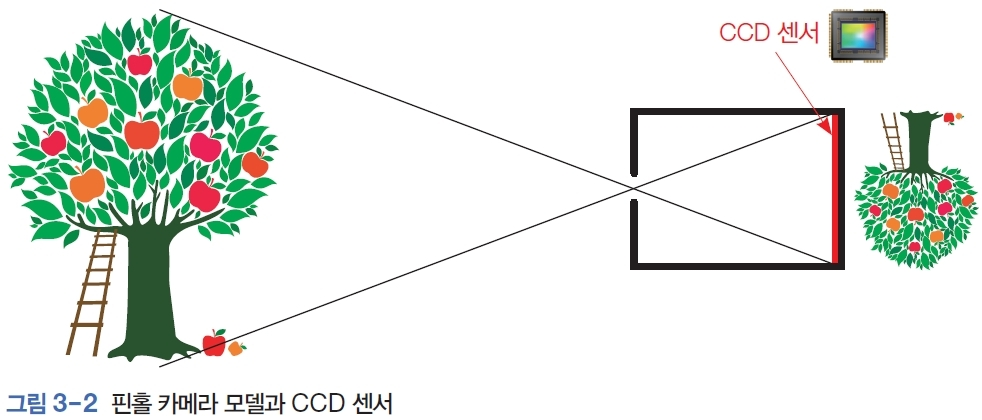

In [2]:
Image("그림 3-2.jpg", width=480)

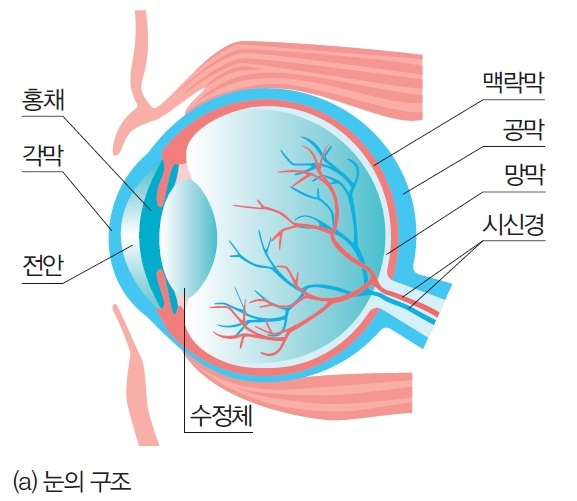

In [3]:
Image("eye.jpg", width=360)

 - 디지털화를 위하여 (공강적, 시간적) 샘플링과 값의 양자화를 수행 

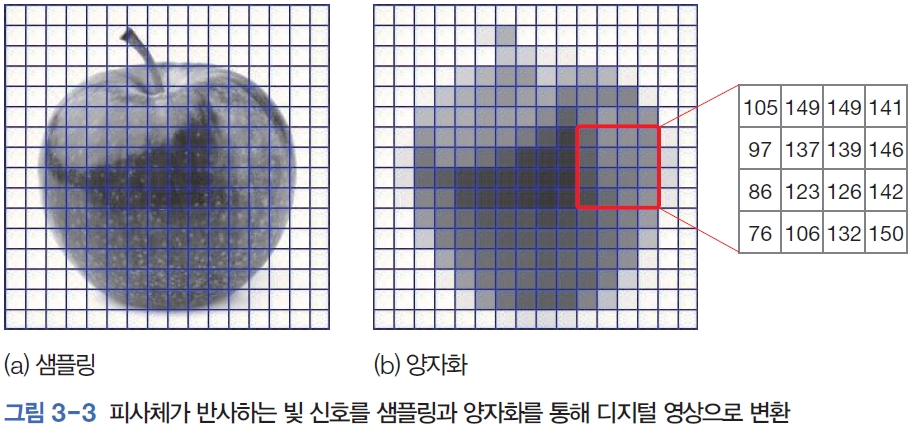

In [4]:
Image("그림 3-3.jpg", width=480)

#### 디지털 영상의 수학적, 프로그램 적 표현 

- 수평 오른쪽 방향을  x, 수직축 ** 아래 ** 방향을 y 축으로 정의함
   - $ I (y, x, c)$ 또는 $I(y,x)$, 
       - $0 <= y < H$ , $ 0 <= x < W $ 즉 3차원 또는 2차원 배녈로 정의    
       - c는 multichannel (예, R, G, B) 의 경우에 각채널을 의미함.
   - 이미지 상의 TOP-LEFT는 원점으로 사용 함 
   - **주의**: 수학에서 많이 쓰는 오른쪽 x, 위쪽 y 를 쓰는 경우도 있음 
   
- OpenCV에서의 표현 

  - opencv는 Python 에서의 이미지 표현으로  numpy ndarray를 사용
  - $ I[y,x, ...] $ 형태로 위와 동일한 좌표 순서와 방향을 사용
  - data type 은 주로 np.uint8을 사용하지만 np.float을 사용하거나 np.boo을 사용하는 경우도 있음. (향후에 다룸)
  - **주의**: 화소의 위치를 지정하는 경우에는 x, y 순서를 사용
      - 예)  cv.line(img, (10,20), (100,200), ...),  (x=10,y=20)에서 (x=100, y=200)으로 하강 대각선으로 선을 그음.
  - **Tip**: 프로그램시에 항상 img.shape, img.dtype 을 확인하여 이미지의 차원과 데이터 타입을 확실히 이해해야함.    
   

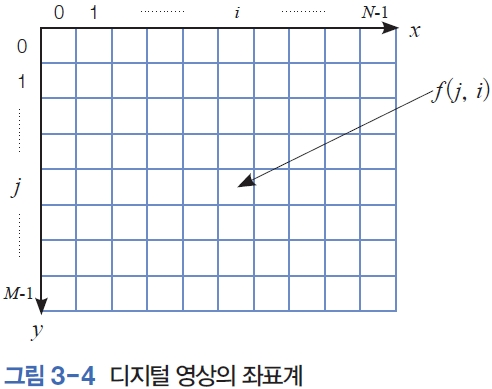

In [5]:
Image("그림 3-4.jpg", width=360)

### 멀티 채널 영상 

본 강의에서는 주로 RGB 영상 및 명암영상, 이진 영상을 사용 
다체널 영상의 응용 

- 위성 영상 (remote sensing) 의 경우 다양한 주파수의 다채널 영상을 사용 
- MRI나 3차원 스캔 등에선는 3차원 영상을 사용함 (x,y,z)
   - 참고로 3 차원 공간정보를 표현 하는 방식은 3D point cloude, Surface mesh 등의 방법도 있음.


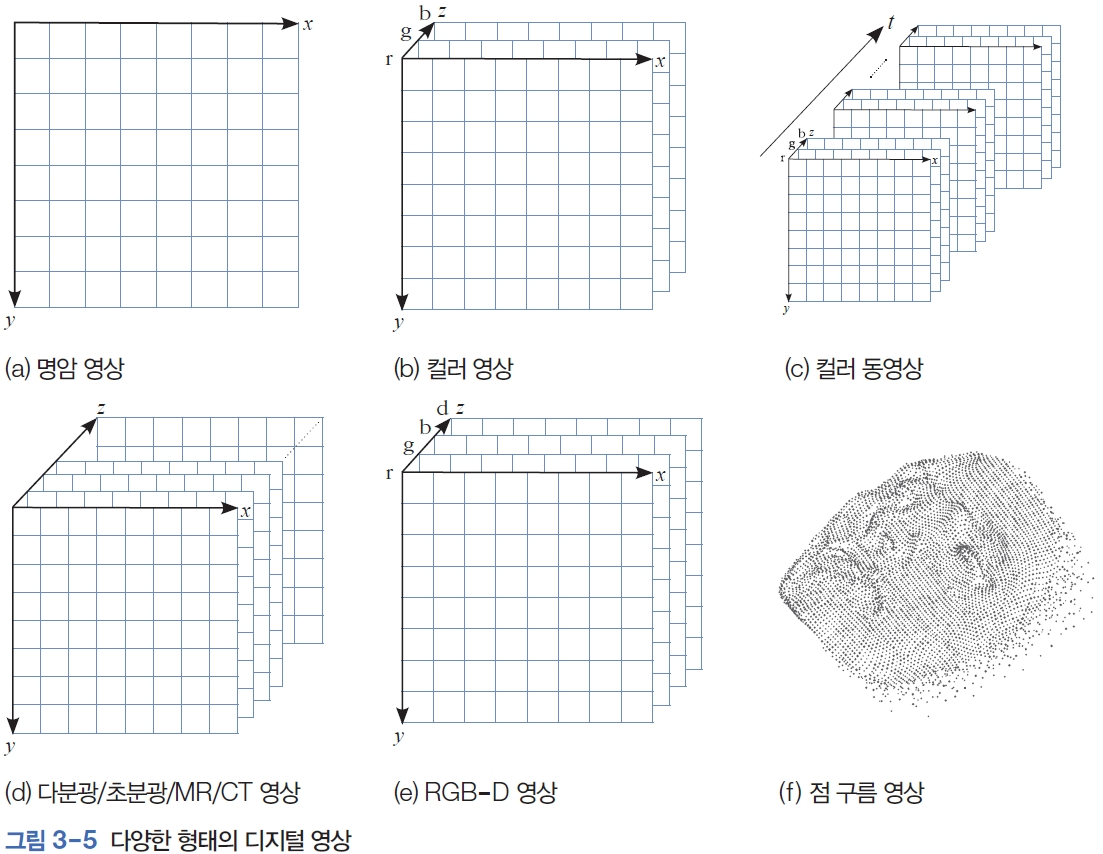

In [6]:
Image("그림 3-5.jpg", width=720)

## 2) 컬러 모델

 - 컬러를 표현하는 방식은 R,G,B 방식이 가장 일반적이지만, 여러가지 다른 표현법이 존재.
 - 본 강의에서는 주로 RGB, HSV 두가징 방식을 사용하므로 이것에 대해서만 설명.

#### RGB

- 가시영역 주파수에 따라 3개의 영역 대표 주파수를 사용  R, G, B  
- 이를 조합하면 사람들의 눈은 중간 주파수로 인식
   - (R + G) 는 두개의 주파수이나 사람의 눈은 Yellow 로 인식함.
   - 이를 이용하여 가시영역 모든 주파수의 색상을 만들수 있음.
- OpenCV에서는 0 ~ 255 값으로 주로 사용, 이론적으로는 (0.0 ,1.0)으로 사용하기도 함

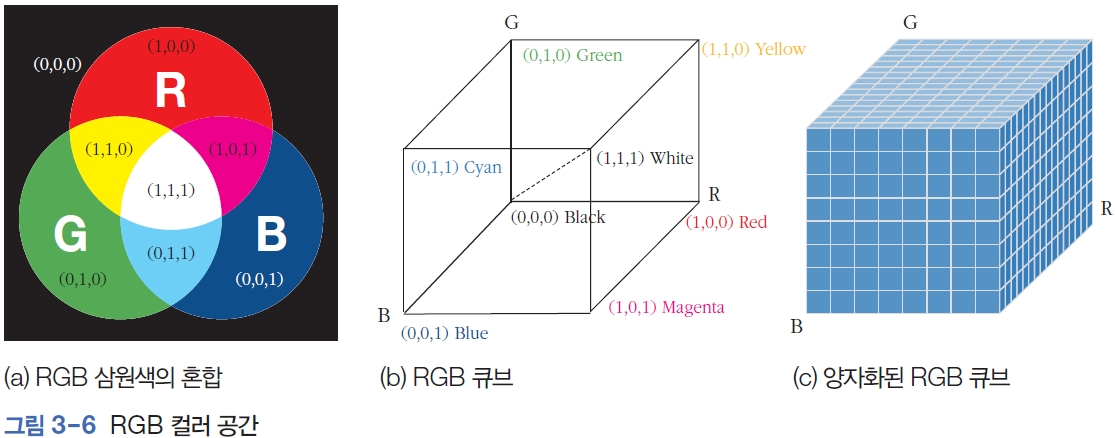

In [7]:
Image("그림 3-6.jpg", width=720)

#### HSV 

- Hue, Saturation, Value : 색상,  순도, 밝기  
    - H (hue) : dominant wavelength   (usu. 0-360o)
    - S (saturation) : the purity of color (0 -100%)
    -V (value) : brightness/luminance  (0 -100%)
    - 각 의미있는 채널로 구분하면 처리가 효과적이거나 쉬운 경우가 상당히 있음.  
        - 예 조명상태에 따라 RGB 모델보다 덜민감 함
        - 자연광 (낮, 저녁), 형광등, 백열등 

- RGV to/from HSV 관계와 변환 
    - 다음과 같은 관계식으로 정의 (상당히 휴리스틱함)
    - $R, G, B : (0,1)$ 
    - $ max = max(R, G, B) $, $min = min(R,G,B)$
    - $V = max(R, G, B)$ 
    - $S = (max -min)/max$  for $V \neq 0$ $S = 0$ for $V = 0$
    - H = $ 60x 0 + (G-B) / (max-min)$ if $max = R$, 
    - H = $ 60x 2 + (B-R) / (max-min)$ if $max = G$,
    - H = $ 60x 4 + (R-G) / (max-min)$ if $max = B$
- OpenCV 에서 생상 변환 
    - Color변환을 하는 cvtColor(img, **변환옵션**) 함수가 있음.
         - COLOR_BGR2HSV/COLOR_HSV2BGR 등  
    - 여기서 값의 범위와 의미
        - uint8 [0,255] 범위로 처리하여야하기 때문에 다소 변화를 줌
        - V (명도): 0 - 255 
        - H (색상): 0 - 179을 사용, 0 = R, 60 = G, 120 = B
           - **주의** 각도는 Circular 특성이 있어 단순 덧셈을 하면 안됨 (%180 모듈러 연산 필요함),   
        - S (순도): 0 - 255  

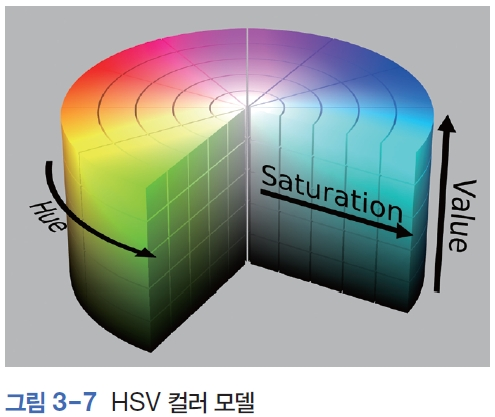

In [8]:
Image("그림 3-7.jpg", width=360)

### 3)  연산의 분류 

- 입력과 출력:  이미지 처리의 입력은 이미지이고 출력도 이미지인 경우가 대부분
- 이미지 처리 비법을 3가지로 구분
 $I_{out}(y', x') =  f( I_{in} (y, x) | (y, x) \in S )$

  -  위치 $(y', x')$의 출력화소값 $I_{out}(y', x')$ 에 영향을 주는 입력화소에 범위에 따라  
  - 점연산:    같은 위치 $(y',x')$ 의 화소 뿐.
  - 영역연산:  (y',x')로 (보통 주변의) 일정영역 $(y,x) \in S(y',x')$ 임,  
  - 기하연산:  일정 함수로 정의되는 위치 $ (y, x) = f(y', x')$의 화소 (와 주변화소)임 



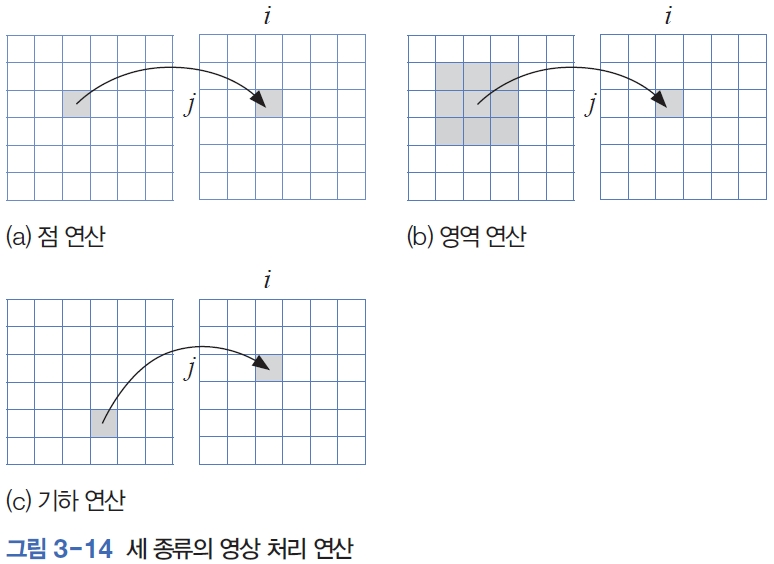

In [9]:
Image("그림 3-14.jpg", width=640)

### 끝